<span style="font-family: Arial; font-weight:bold;font-size:1.9em;color:#0e92ea">Case Study
    <span style="font-family: Arial; font-weight:bold;font-size:0.7em;color:#b53f05"> (Suicide Rates Overview 1985 to 2016)

Our aim is to explore the data of suicide rates.

Lets start using the above techniques on a practical dataset. We will be using data about suicide rates from 1985 to 2026.

source: https://www.kaggle.com/russellyates88/suicide-rates-overview-1985-to-2016


Dataset Feature List
country
year
sex
age
suicides_no
population
suicides/100k pop
country-year
HDI for year
gdp_for_year
gdp_per_capita
generation

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea;">1.1 Load the libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea;">1.2. Import the dataset(suicide_data.csv):

In [2]:
data  = pd.read_csv("Suicide_data.csv") # Import the dataset 
data.head()  # view the first 5 rows of the data

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.3 Check the data.describe()

In [3]:
data.describe()

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
count,27820.000000,27820.000000,2.782000e+04,27820.000000,8364.000000,27820.000000
mean,2001.258375,242.574407,1.844794e+06,12.816097,0.776601,16866.464414
std,8.469055,902.047917,3.911779e+06,18.961511,0.093367,18887.576472
min,1985.000000,0.000000,2.780000e+02,0.000000,0.483000,251.000000
25%,1995.000000,3.000000,9.749850e+04,0.920000,0.713000,3447.000000
50%,2002.000000,25.000000,4.301500e+05,5.990000,0.779000,9372.000000
75%,2008.000000,131.000000,1.486143e+06,16.620000,0.855000,24874.000000
max,2016.000000,22338.000000,4.380521e+07,224.970000,0.944000,126352.000000


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.4 Check the data set information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.5 Check for missing values

In [5]:
def missing_check(df):
    total = df.isnull().sum().sort_values(ascending=False)   # total number of null values
    percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)  # percentage of values that are null
    Datatype = df.dtypes
    missing_data = pd.concat([total, percent, Datatype], axis=1, keys=['Total', 'Percent','Datatype'])  # putting the above two together
    return missing_data # return the dataframe
missing_check(data)

,Total,Percent,Datatype
HDI for year,19456,0.699353,float64
country,0,0.000000,object
year,0,0.000000,int64
sex,0,0.000000,object
age,0,0.000000,object
suicides_no,0,0.000000,int64
population,0,0.000000,int64
suicides/100k pop,0,0.000000,float64
country-year,0,0.000000,object
gdp_for_year ($),0,0.000000,object


In [6]:
### DATA SHAPE
data.shape

(27820, 12)

list

In [7]:
# Make list of all columns with Object datatype

Obj_dtype = [ col for col in data.columns if data[col].dtype == 'object' ]
num_dtype = [ col for col in data.columns if data[col].dtype != 'object' ]
print(f"Object columns: {Obj_dtype}")
print(f"Numeric columns: {num_dtype}")

Object columns: ['country', 'sex', 'age', 'country-year', ' gdp_for_year ($) ', 'generation']
Numeric columns: ['year', 'suicides_no', 'population', 'suicides/100k pop', 'HDI for year', 'gdp_per_capita ($)']


In [8]:
for col in Obj_dtype:
    print(data[col].value_counts())
    print()

country
Mauritius                 382
Austria                   382
Netherlands               382
Iceland                   382
Brazil                    372
                         ... 
Bosnia and Herzegovina     24
Cabo Verde                 12
Dominica                   12
Macau                      12
Mongolia                   10
Name: count, Length: 101, dtype: int64

sex
male      13910
female    13910
Name: count, dtype: int64

age
15-24 years    4642
35-54 years    4642
75+ years      4642
25-34 years    4642
55-74 years    4642
5-14 years     4610
Name: count, dtype: int64

country-year
Albania1987     12
Poland1993      12
Panama2009      12
Panama2010      12
Panama2011      12
                ..
Austria2016     10
Croatia2016     10
Hungary2016     10
Armenia2016     10
Mongolia2016    10
Name: count, Length: 2321, dtype: int64

 gdp_for_year ($) 
2,156,624,900      12
96,045,645,026     12
27,116,635,600     12
29,440,287,600     12
34,686,224,300     12
                

# Bivariate Analysis

## Categorical Plots

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.7 Bar plot to check Number of Suicides by Countries

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.7a Bar plot to check Number of Suicides by top Countries

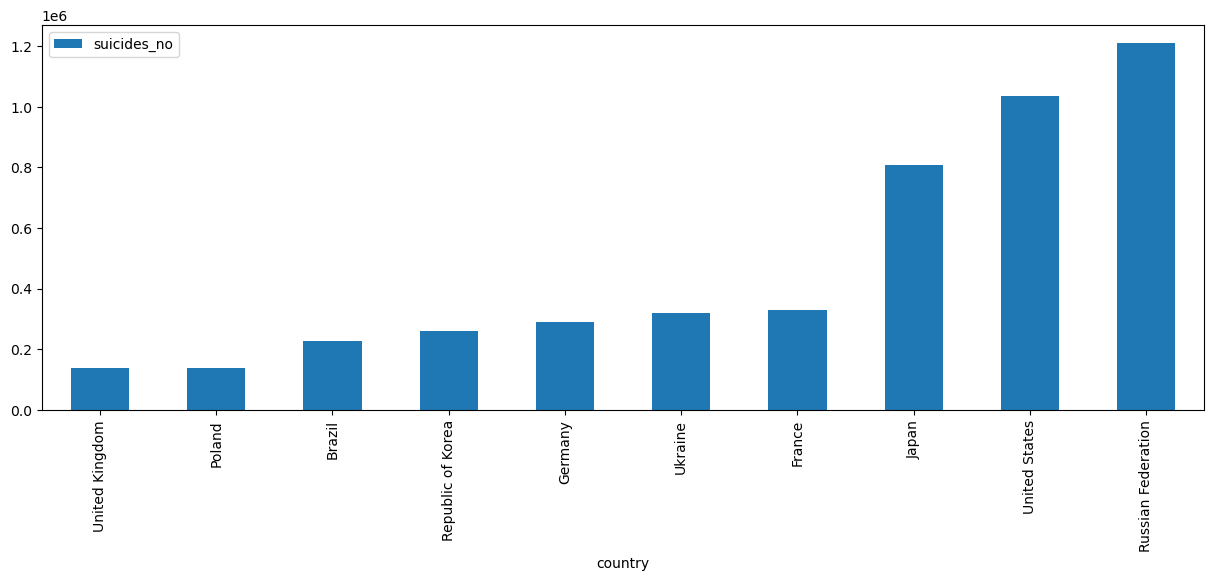

In [9]:
data.groupby(by='country')['suicides_no'].sum().reset_index().sort_values(['suicides_no']).tail(10).plot(x='country',
                                                                                                        y='suicides_no',
                                                                                                        kind='bar',
                                                                                                        figsize=(15,5));

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.7b Bar plot to check Number of Suicides by Bottom Countries

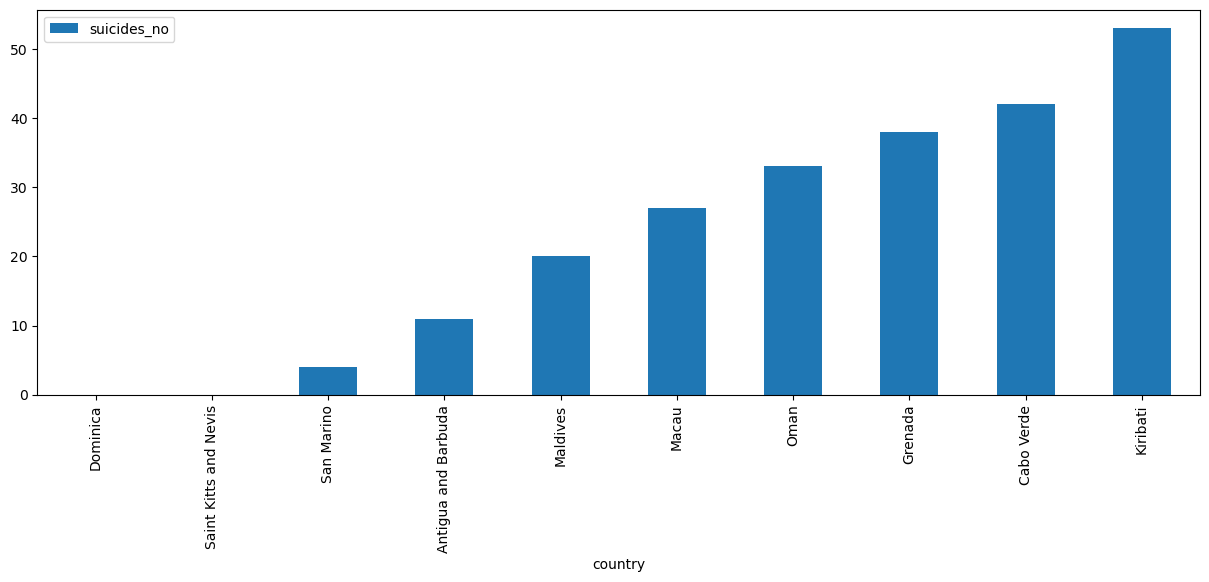

In [10]:
data.groupby(by='country')['suicides_no'].sum().reset_index().sort_values(['suicides_no']).head(10).plot(x='country',
                                                                                                        y='suicides_no',
                                                                                                        kind='bar',
                                                                                                        figsize=(15,5));

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.8 Bar plot for Number of Suicides Vs Age

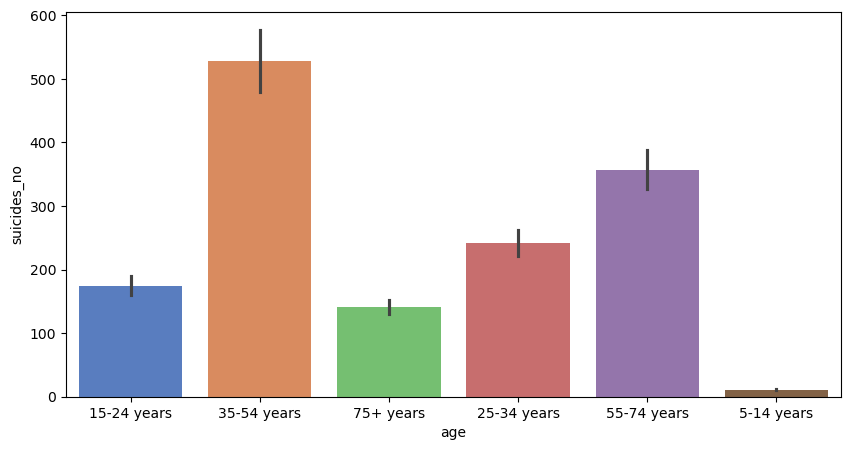

In [11]:
plt.figure(figsize=(10,5))  # setting the figure size
ax = sns.barplot(x='age', y='suicides_no', data=data, palette='muted')  # barplot

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.8 Bar plot for Number of Suicides Vs Generation

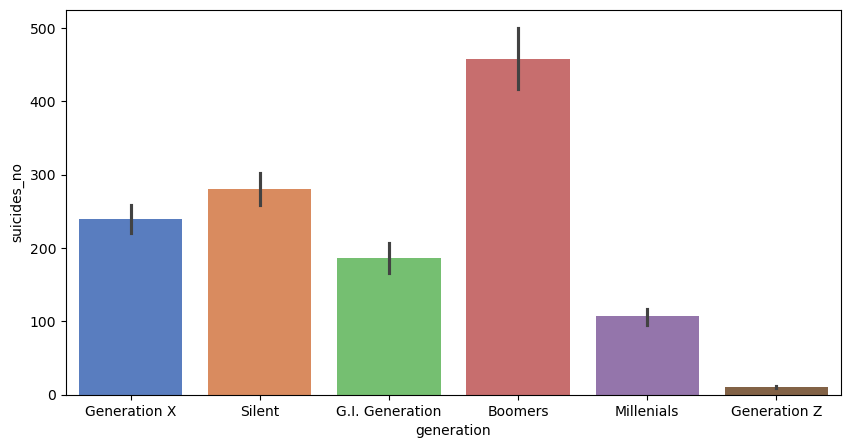

In [12]:
plt.figure(figsize=(10,5))  # setting the figure size
ax = sns.barplot(x='generation', y='suicides_no', data=data, palette='muted')  # barplot

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.9 Bar plot for Number of Suicides Vs Sex

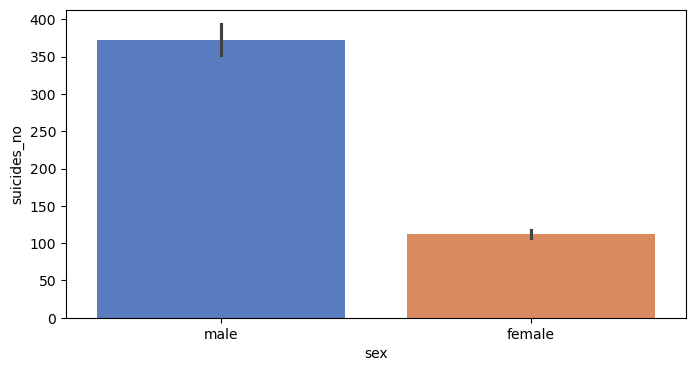

In [13]:
plt.figure(figsize=(8,4))
ax = sns.barplot(x="sex", y="suicides_no", data=data, palette='muted')

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.9.a Bar plot To check Number of suicides by sex and age 

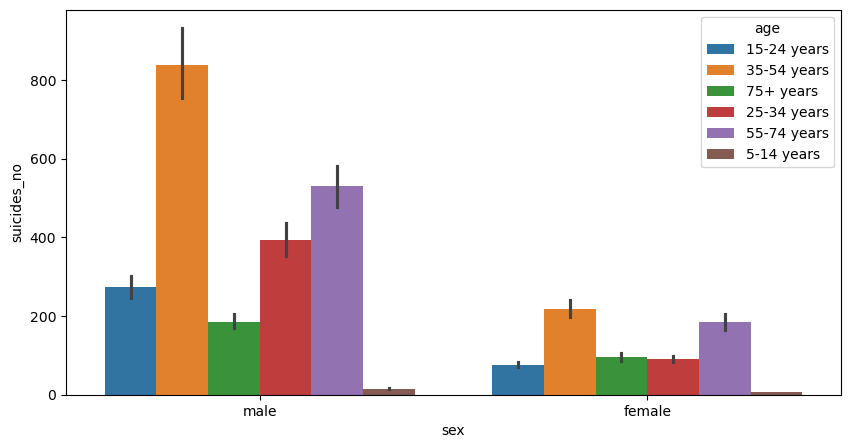

In [14]:
plt.figure(figsize=(10,5))  # setting the figure size
ax = sns.barplot(x='sex', y='suicides_no', data=data, hue='age')  # barplot

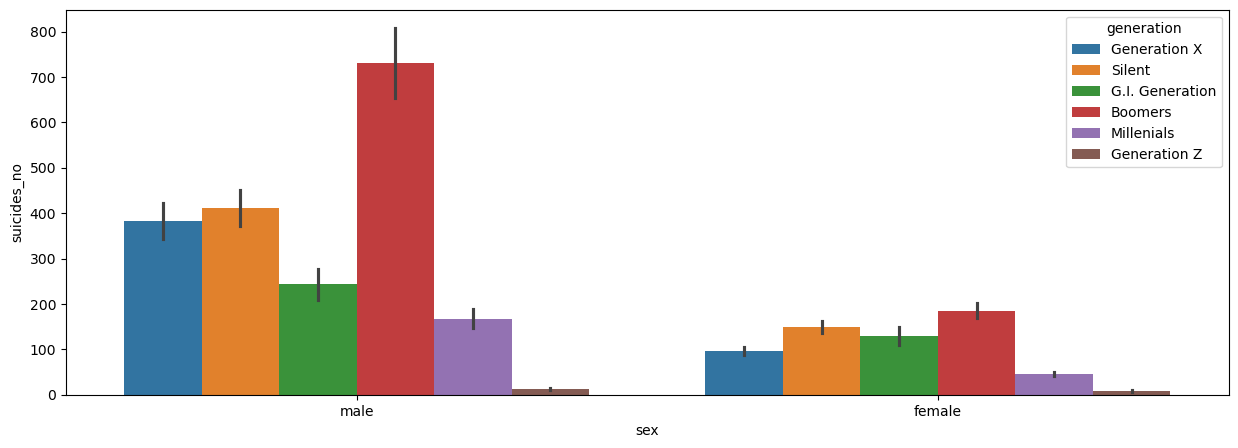

In [15]:
plt.figure(figsize=(15,5))
sns.barplot(data=data,x='sex',y='suicides_no',hue='generation')
plt.show()

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea"> 1.10 Checking the No.of suicides: Country Vs Sex

In [16]:
suicide_country_high = data['suicides_no'].groupby([data['country'],data['sex']]).sum().reset_index().sort_values(['suicides_no'],ascending= False)
suicide_country_high 

,country,sex,suicides_no
151,Russian Federation,male,995412
197,United States,male,820216
93,Japan,male,555272
191,Ukraine,male,258573
92,Japan,female,251630
...,...,...,...
152,Saint Kitts and Nevis,female,0
54,Dominica,female,0
153,Saint Kitts and Nevis,male,0
130,Oman,female,0


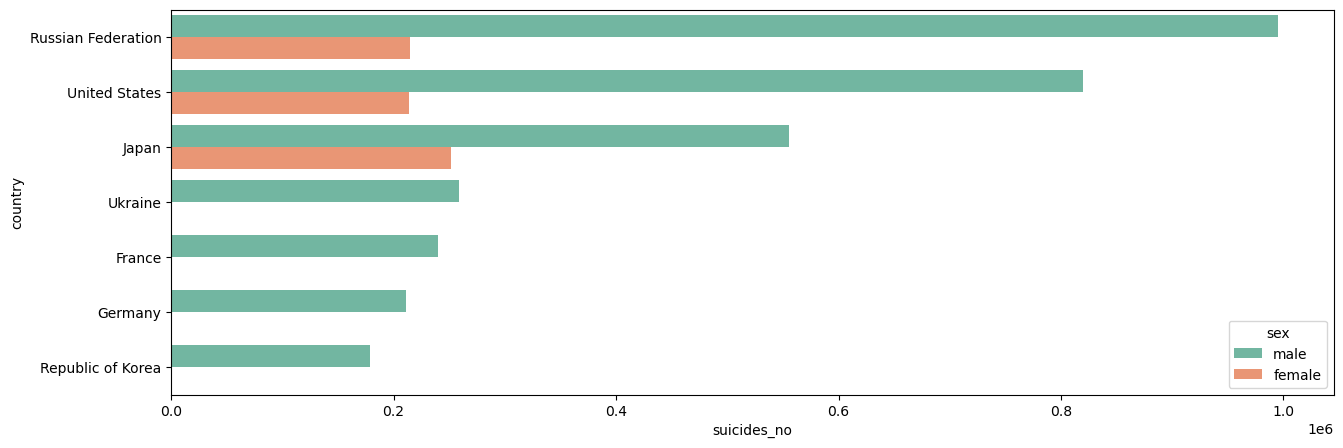

In [17]:
plt.subplots(figsize=(15,5))
sns.barplot(data=suicide_country_high.head(10),y='country',x='suicides_no',hue='sex',palette='Set2');

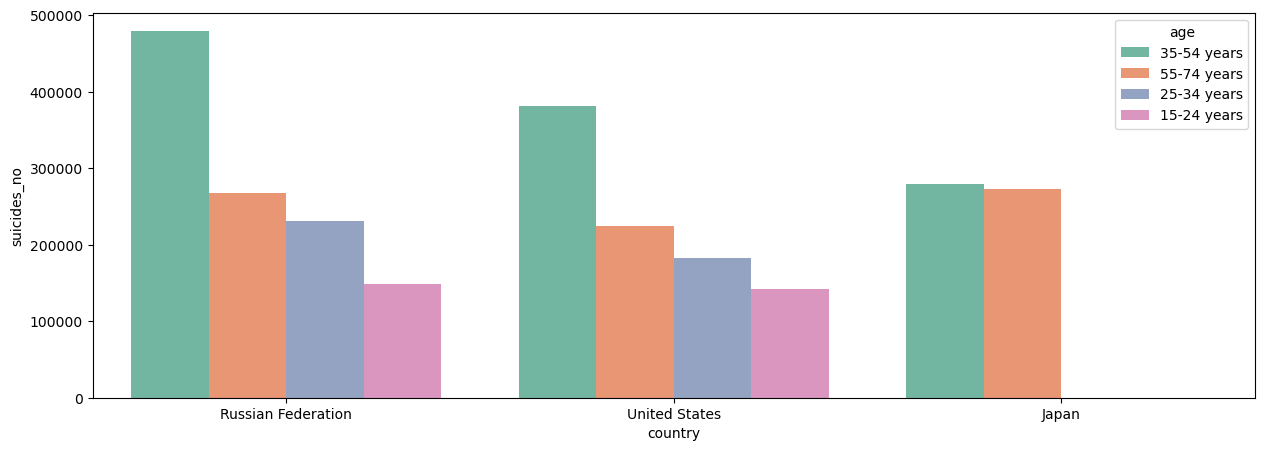

In [18]:
suicide_country_age = data['suicides_no'].groupby([data['country'],data['age']]).sum().reset_index().sort_values(['suicides_no'],ascending= False)
plt.subplots(figsize=(15,5))
sns.barplot(data=suicide_country_age.head(10),y='suicides_no',x='country',hue='age',palette='Set2');

## Numeric plots

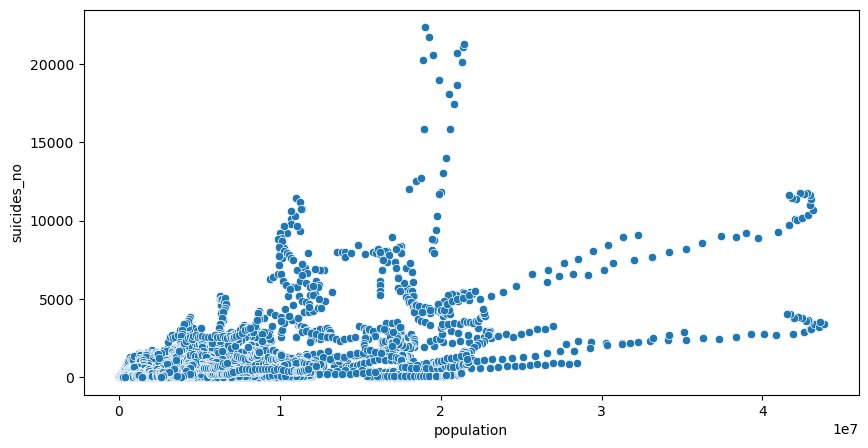

In [19]:
plt.figure(figsize=(10,5))
ax = sns.scatterplot(data=data, x='population',y='suicides_no');


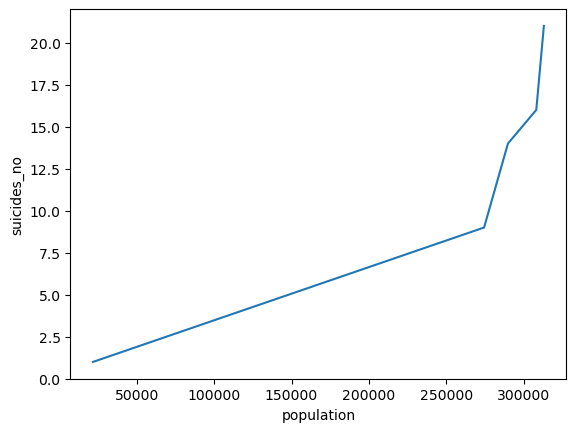

In [20]:
#Here we plotting a line plot.
sns.lineplot(x='population',y='suicides_no', data=data.head() );


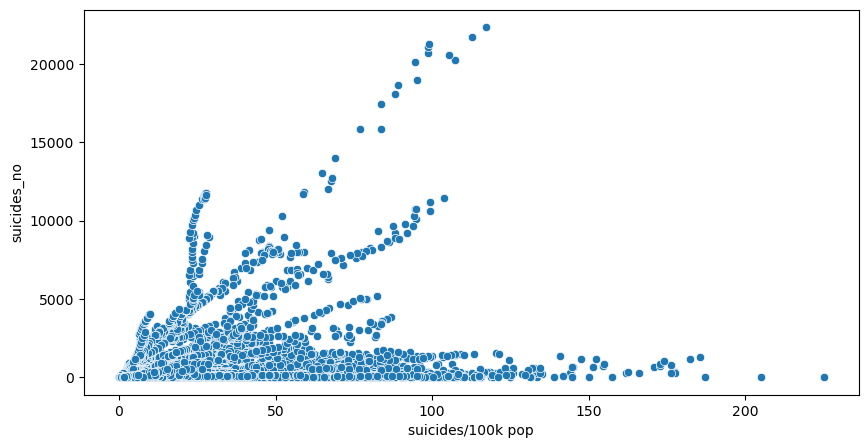

In [21]:
plt.figure(figsize=(10,5))
ax = sns.scatterplot(data=data, x='suicides/100k pop',y='suicides_no');

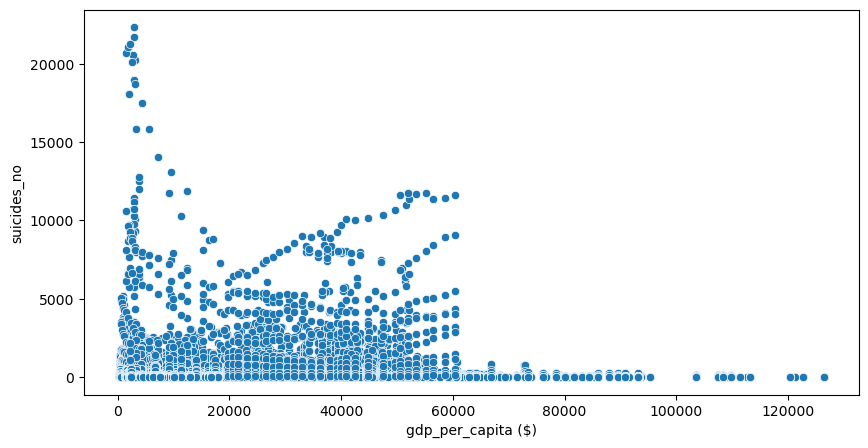

In [22]:
plt.figure(figsize=(10,5))
ax = sns.scatterplot(data=data, x='gdp_per_capita ($)',y='suicides_no');

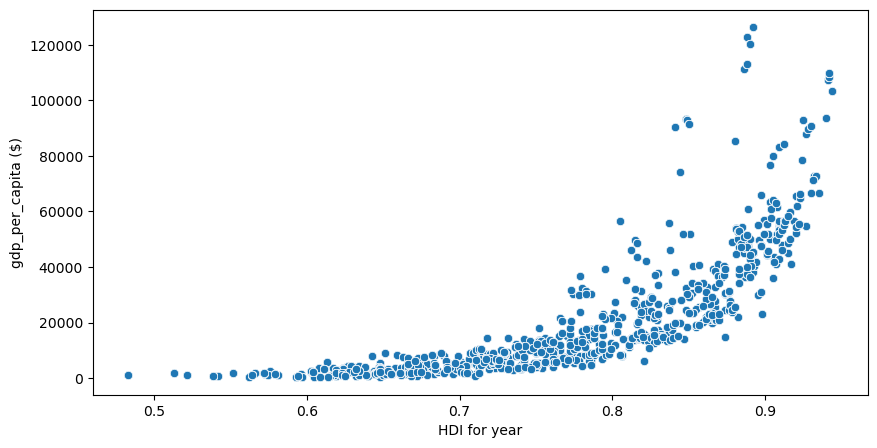

In [23]:
plt.figure(figsize=(10,5))
ax = sns.scatterplot(data=data, y='gdp_per_capita ($)',x='HDI for year');

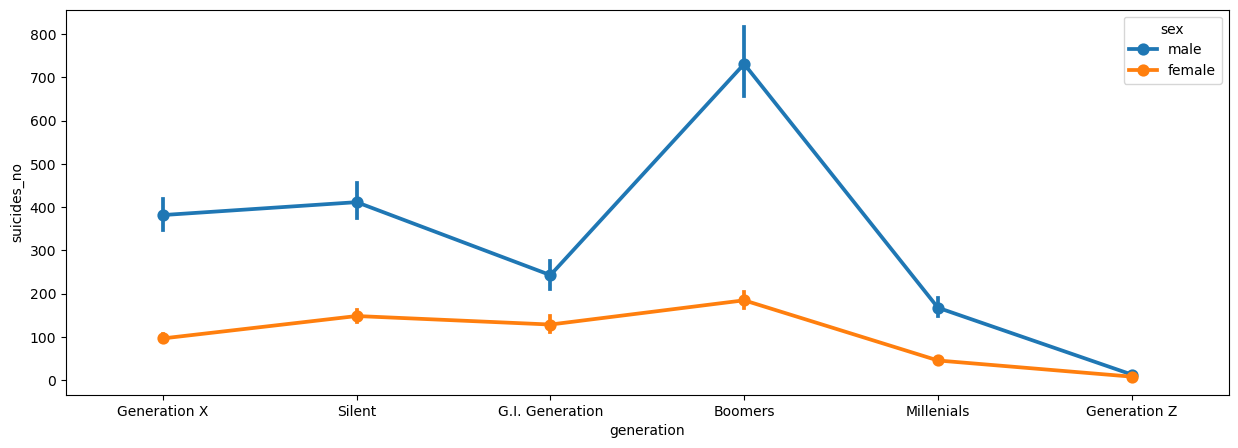

In [24]:
plt.figure(figsize=(15,5))
sns.pointplot(data=data,x='generation',y='suicides_no',hue='sex')
plt.show()

# Univariate Analysis

Mean:  242.57440690150972 
Median:  25.0 
Mode:  0


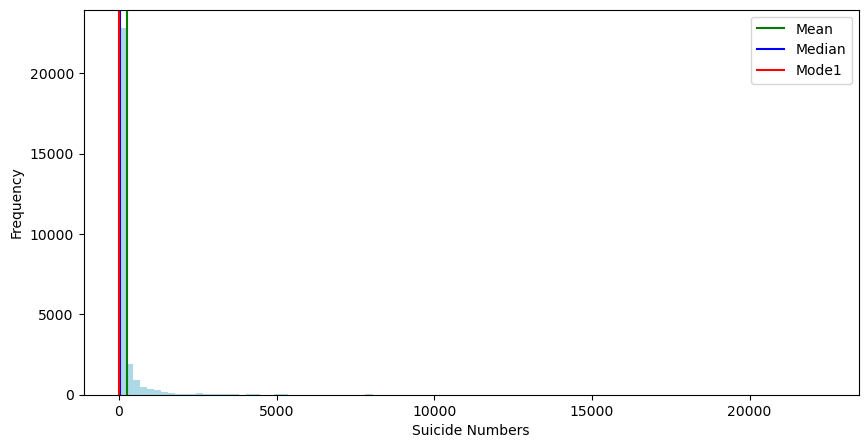

In [25]:
mean=data['suicides_no'].mean()
median=data['suicides_no'].median()
mode=data['suicides_no'].mode()

print('Mean: ',mean,'\nMedian: ',median,'\nMode: ',mode[0])

plt.figure(figsize=(10,5)) # set the figure size
plt.hist(data['suicides_no'],bins=100,color='lightblue') #Plot the histogram

plt.axvline(mean,color='green',label='Mean')     # Draw lines on the plot for mean median and the two modes we have in GRE Score
plt.axvline(median,color='blue',label='Median')
plt.axvline(mode[0],color='red',label='Mode1')

plt.xlabel('Suicide Numbers')   # label the x-axis
plt.ylabel('Frequency')   # label the y-axis
plt.legend()              # Plot the legend
plt.show()

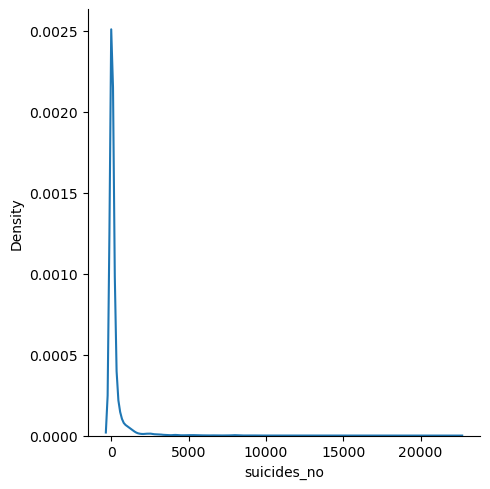

In [26]:
sns.displot(data['suicides_no'],kind='kde');

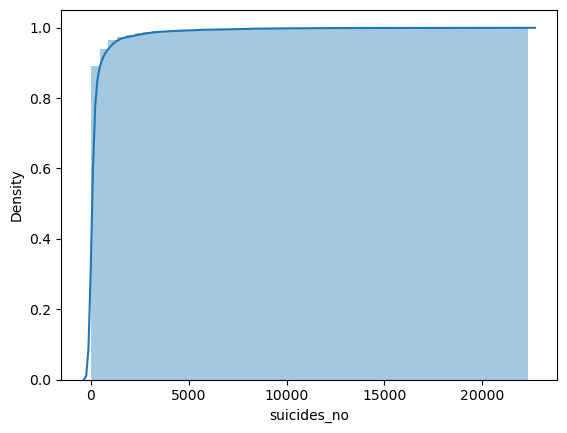

In [27]:
sns.distplot(data['suicides_no'], hist_kws=dict(cumulative=True), kde_kws=dict(cumulative=True));

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.11 Check Covariance and Correlation

In [28]:
data.cov(numeric_only=True)# Prints the covariance of each attribute against every other attribute

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
year,71.724893,-3.472881e+01,2.931979e+05,-6.268766,0.301465,5.424789e+04
suicides_no,-34.728813,8.136904e+05,2.174198e+09,5244.221253,9.626404,1.044906e+06
population,293197.948495,2.174198e+09,1.530202e+13,614523.369015,38155.267225,6.022277e+09
suicides/100k pop,-6.268766,5.244221e+03,6.145234e+05,359.538900,0.120407,6.393224e+02
HDI for year,0.301465,9.626404e+00,3.815527e+04,0.120407,0.008717,1.625860e+03
gdp_per_capita ($),54247.893806,1.044906e+06,6.022277e+09,639.322444,1625.859616,3.567405e+08


In [29]:
data.corr(numeric_only=True)# Prints the covariance of each attribute against every other attribute

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
year,1.000000,-0.004546,0.008850,-0.039037,0.366786,0.339134
suicides_no,-0.004546,1.000000,0.616162,0.306604,0.151399,0.061330
population,0.008850,0.616162,1.000000,0.008285,0.102943,0.081510
suicides/100k pop,-0.039037,0.306604,0.008285,1.000000,0.074279,0.001785
HDI for year,0.366786,0.151399,0.102943,0.074279,1.000000,0.771228
gdp_per_capita ($),0.339134,0.061330,0.081510,0.001785,0.771228,1.000000


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;"> 1.11a. Heatmap for checking the correlation

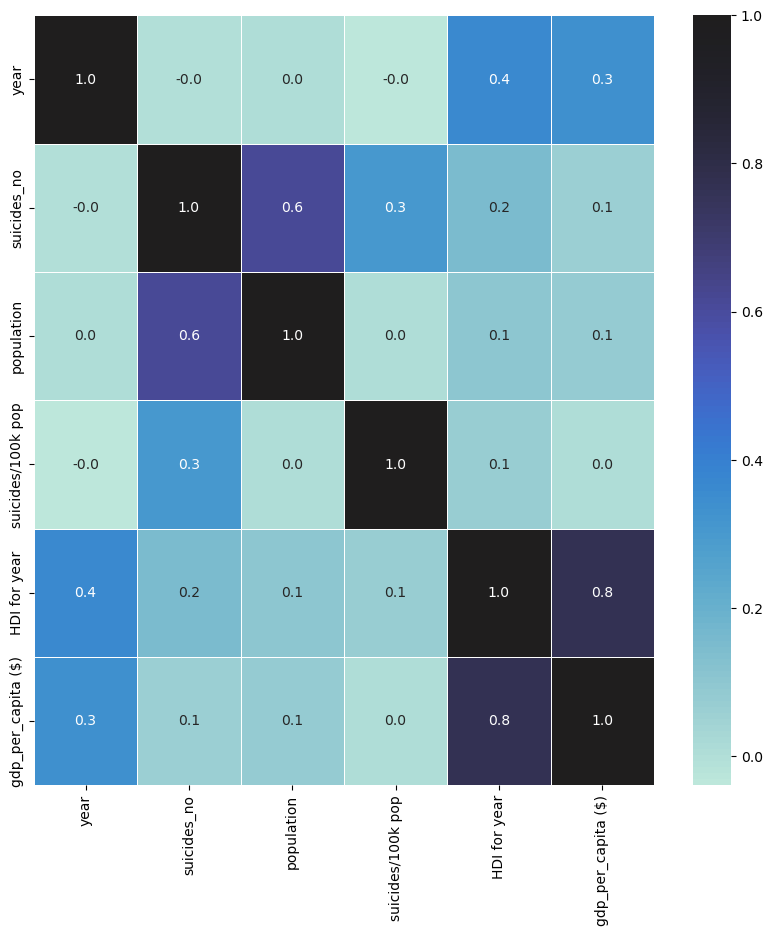

In [30]:
fig,ax = plt.subplots(figsize=(10, 10))   
sns.heatmap(data.corr(numeric_only=True), annot=True, linewidths=.5, fmt= '.1f', center = 1 ) # the color intensity is based on 
plt.show()

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;"> 1.11b. Pairplot for checking the correlation

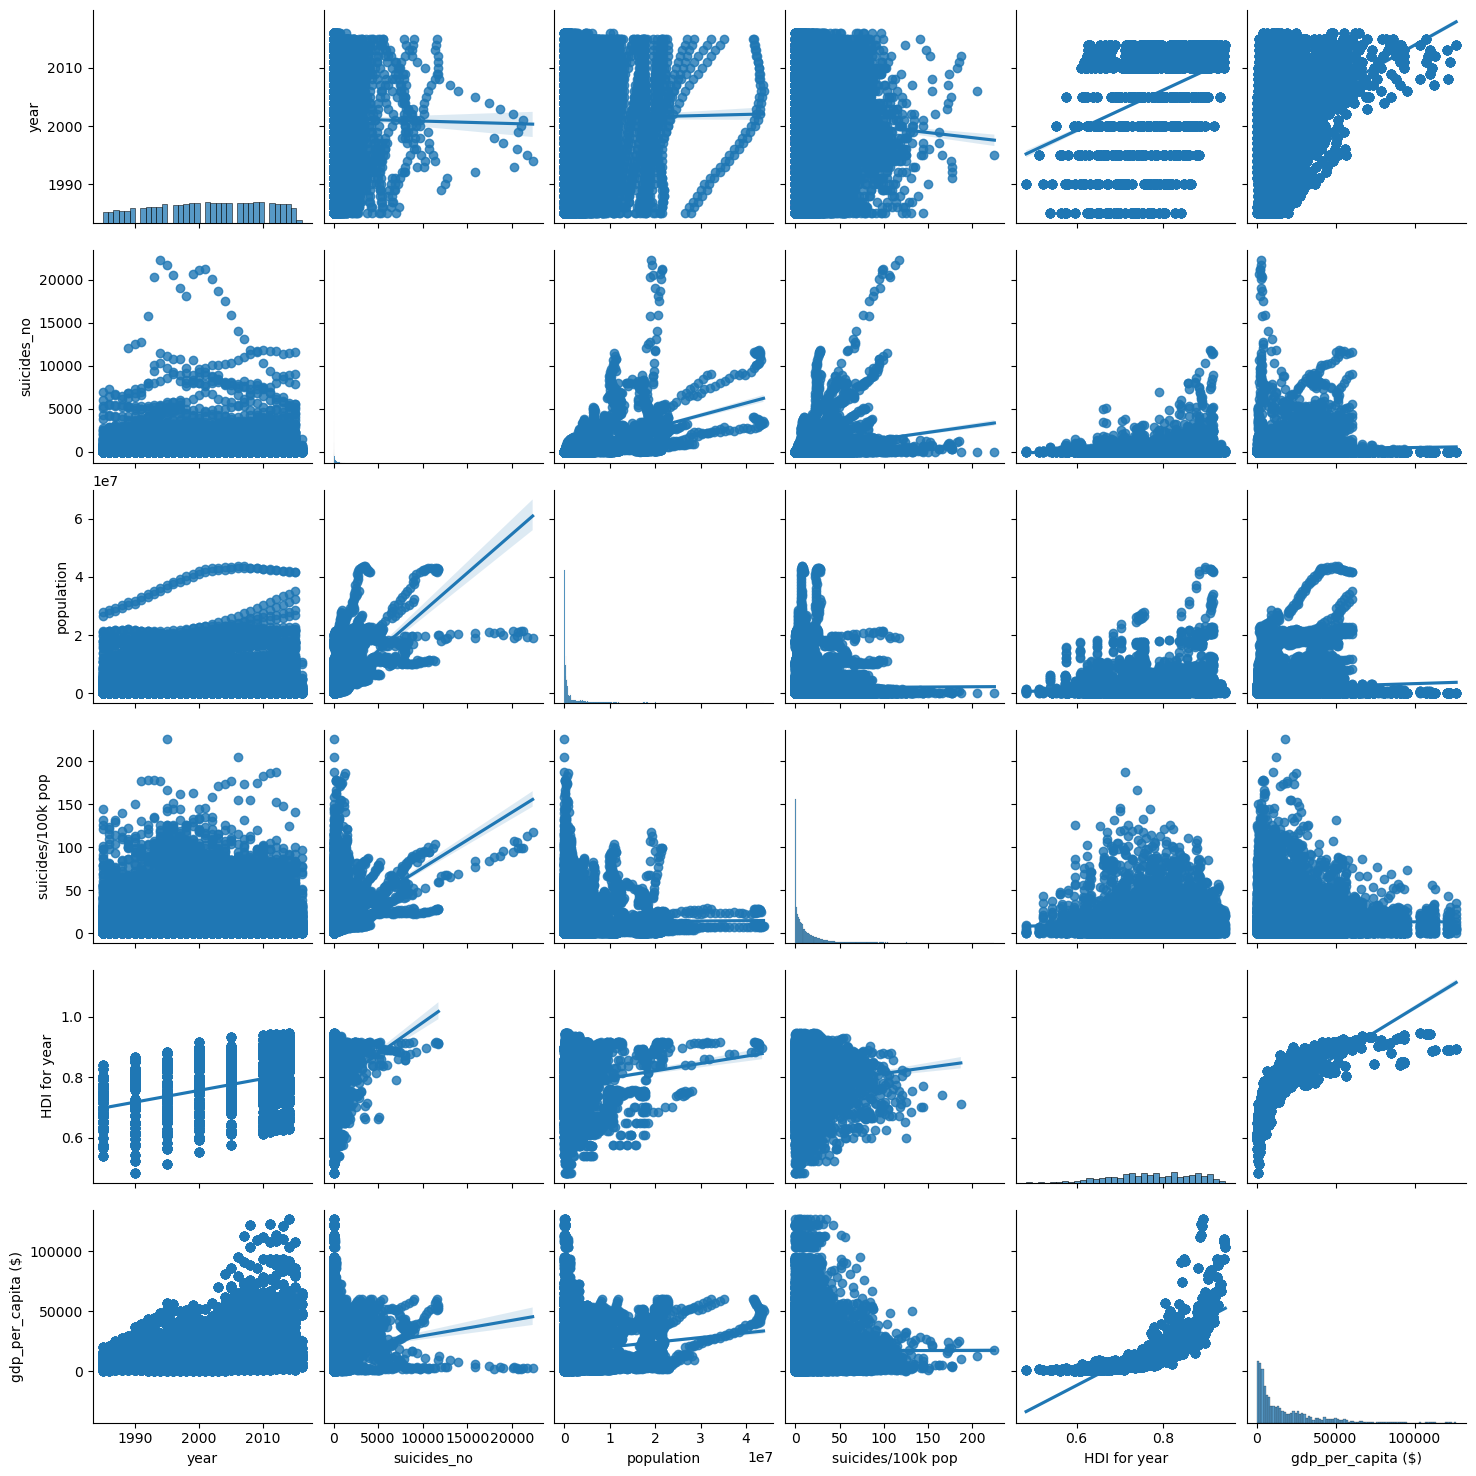

In [31]:
sns.pairplot(data, kind="reg")  # plots scatter plots for every pair of attributes and histograms along the diagonal
plt.show()